**Експериментальні залежності інтенсивності випромінювання лазера від довжини хвилі для всіх
значень температури**

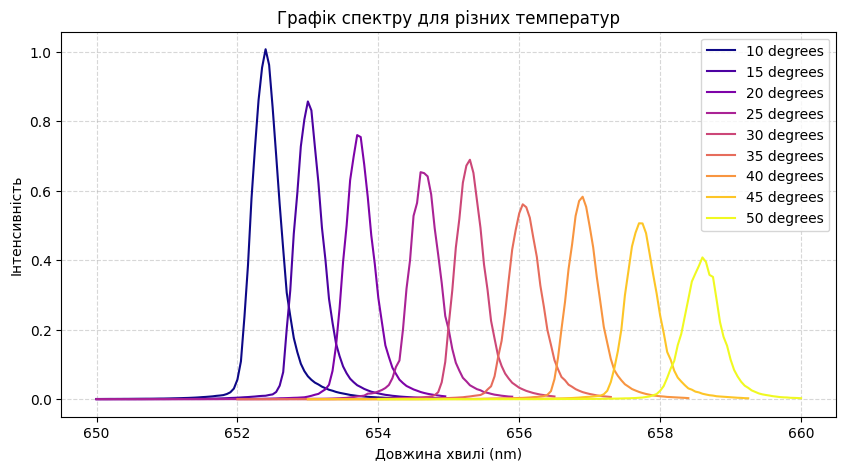

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def load_data(filename):
    wavelengths, intensities = [], []
    with open(filename, 'r', encoding='utf-8') as file:
        next(file)  # Пропускаємо заголовок
        for line in file:
            parts = line.split()
            if len(parts) == 2:
                wavelengths.append(float(parts[0]))
                intensities.append(float(parts[1]))
    return np.array(wavelengths), np.array(intensities)

# Список файлів
angles = [10, 15, 20, 25, 30, 35, 40, 45, 50]
files = [f"{angle} degrees.txt" for angle in angles]
colors = plt.cm.plasma(np.linspace(0, 1, len(files)))  # Генеруємо кольори

# Побудова графіка
plt.figure(figsize=(10, 5), dpi=100)

for file, angle, color in zip(files, angles, colors):
    wavelengths, intensities = load_data(file)
    plt.plot(wavelengths, intensities, label=f"{angle} degrees", color=color)

plt.xlabel("Довжина хвилі (nm)")
plt.ylabel("Інтенсивність")
plt.title("Графік спектру для різних температур")
plt.legend()
plt.grid(which='both', linestyle='--', alpha=0.5)

# Збереження зображення
plt.savefig("spectrum_plot.png")
plt.show()


**Експериментальні залежності інтенсивності випромінювання лазера від енергії кванту для всіх значень температури.**

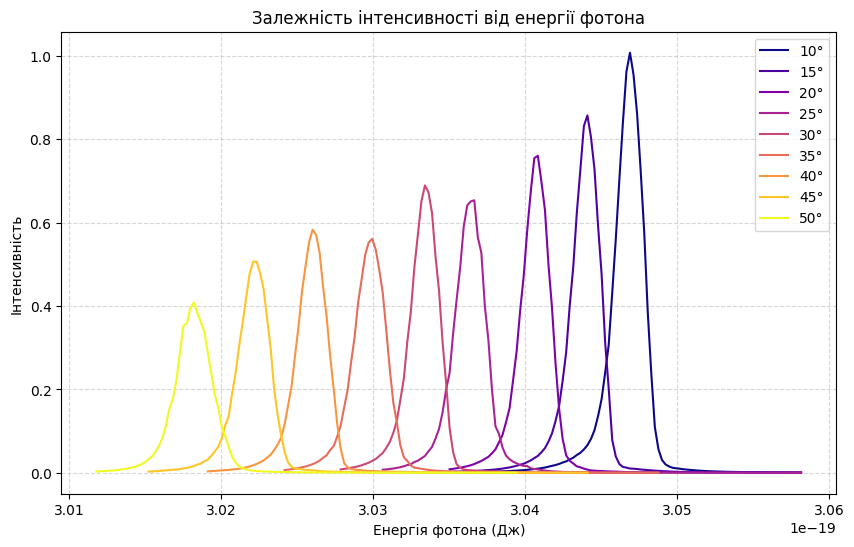

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Фізичні константи
h = 6.626e-34  # Дж·с (стала Планка)
c = 3.0e8      # м/с (швидкість світла)

def calculate_quantum_energy(wavelengths):
    """Обчислення енергії фотонів за довжиною хвилі"""
    wavelengths_m = wavelengths * 1e-9  # Перетворення нм -> м
    return (h * c) / wavelengths_m  # E = hc/λ

def load_data(filename):
    """Завантаження даних з файлу"""
    wavelengths, intensities = [], []

    if not os.path.exists(filename):
        print(f"Файл {filename} не знайдено!")
        return None, None

    with open(filename, 'r', encoding='utf-8') as file:
        next(file)  # Пропускаємо заголовок
        for line in file:
            parts = line.split()
            if len(parts) == 2:
                wavelengths.append(float(parts[0]))
                intensities.append(float(parts[1]))

    return np.array(wavelengths), np.array(intensities)

# Список файлів
angles = [10, 15, 20, 25, 30, 35, 40, 45, 50]
files = [f"{angle} degrees.txt" for angle in angles]

# Зчитування та обробка даних
data = {}
for file, angle in zip(files, angles):
    wavelengths, intensities = load_data(file)

    if wavelengths is not None and intensities is not None:
        energies = calculate_quantum_energy(wavelengths)
        data[angle] = (energies, intensities)

# Побудова графіка
def plot_intensity_vs_energy(data):
    """Графік залежності інтенсивності від енергії фотонів"""
    plt.figure(figsize=(10, 6), dpi=100)
    colors = plt.cm.plasma(np.linspace(0, 1, len(data)))

    for (angle, (energies, intensities)), color in zip(data.items(), colors):
        plt.plot(energies, intensities, label=f"{angle}°", color=color)

    plt.xlabel("Енергія фотона (Дж)")
    plt.ylabel("Інтенсивність")
    plt.title("Залежність інтенсивності від енергії фотона")
    plt.legend()
    plt.grid(which='both', linestyle='--', alpha=0.5)
    plt.savefig("intensity_vs_energy.png")
    plt.show()

# Викликаємо функцію побудови графіка
plot_intensity_vs_energy(data)


**Те саме. Просто з проміжними результатами**

Файл 10 degrees.txt: 91 точок, приклади -> λ: [650.   650.05 650.1  650.15 650.2 ] нм, I: [0.00096914 0.00095312 0.00103522 0.00108928 0.00116738]
Приклад розрахунку енергії: [650.   650.05 650.1  650.15 650.2 ] нм -> [3.05815385e-19 3.05791862e-19 3.05768343e-19 3.05744828e-19
 3.05721317e-19] Дж
Файл 15 degrees.txt: 101 точок, приклади -> λ: [650.   650.05 650.1  650.15 650.2 ] нм, I: [0.00047256 0.00048057 0.00048858 0.00045053 0.00055465]
Приклад розрахунку енергії: [650.   650.05 650.1  650.15 650.2 ] нм -> [3.05815385e-19 3.05791862e-19 3.05768343e-19 3.05744828e-19
 3.05721317e-19] Дж
Файл 20 degrees.txt: 100 точок, приклади -> λ: [650.   650.05 650.1  650.15 650.2 ] нм, I: [0.00044052 0.00046054 0.00043451 0.00044853 0.00047056]
Приклад розрахунку енергії: [650.   650.05 650.1  650.15 650.2 ] нм -> [3.05815385e-19 3.05791862e-19 3.05768343e-19 3.05744828e-19
 3.05721317e-19] Дж
Файл 25 degrees.txt: 119 точок, приклади -> λ: [650.   650.05 650.1  650.15 650.2 ] нм, I: [0.0003944

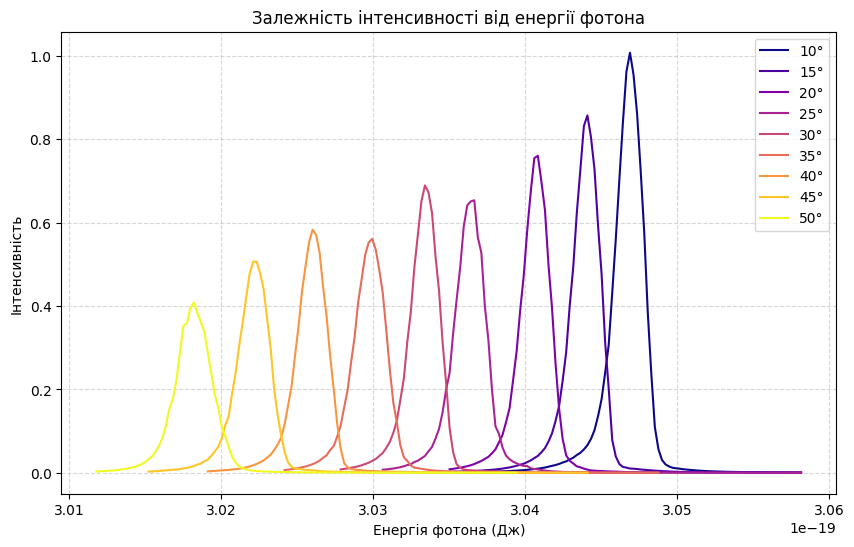

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Фізичні константи
h = 6.626e-34  # Дж·с (стала Планка)
c = 3.0e8      # м/с (швидкість світла)

def calculate_quantum_energy(wavelengths):
    """Обчислення енергії фотонів за довжиною хвилі"""
    wavelengths_m = wavelengths * 1e-9  # Перетворення нм -> м
    energies = (h * c) / wavelengths_m  # E = hc/λ

    # Виведемо приклади для перевірки
    print(f"Приклад розрахунку енергії: {wavelengths[:5]} нм -> {energies[:5]} Дж")

    return energies

def load_data(filename):
    """Завантаження даних з файлу"""
    wavelengths, intensities = [], []

    if not os.path.exists(filename):
        print(f"Файл {filename} не знайдено!")
        return None, None

    with open(filename, 'r', encoding='utf-8') as file:
        next(file)  # Пропускаємо заголовок
        for line in file:
            parts = line.split()
            if len(parts) == 2:
                try:
                    wavelengths.append(float(parts[0]))
                    intensities.append(float(parts[1]))
                except ValueError:
                    print(f"Помилка читання у файлі {filename}: {line.strip()}")

    wavelengths = np.array(wavelengths)
    intensities = np.array(intensities)

    # Виведемо приклад зчитаних значень
    print(f"Файл {filename}: {len(wavelengths)} точок, приклади -> λ: {wavelengths[:5]} нм, I: {intensities[:5]}")

    return wavelengths, intensities

# Список файлів
angles = [10, 15, 20, 25, 30, 35, 40, 45, 50]
files = [f"{angle} degrees.txt" for angle in angles]

# Зчитування та обробка даних
data = {}
for file, angle in zip(files, angles):
    wavelengths, intensities = load_data(file)

    if wavelengths is not None and intensities is not None:
        energies = calculate_quantum_energy(wavelengths)
        data[angle] = (energies, intensities)

# Побудова графіка
def plot_intensity_vs_energy(data):
    """Графік залежності інтенсивності від енергії фотонів"""
    plt.figure(figsize=(10, 6), dpi=100)
    colors = plt.cm.plasma(np.linspace(0, 1, len(data)))

    for (angle, (energies, intensities)), color in zip(data.items(), colors):
        plt.plot(energies, intensities, label=f"{angle}°", color=color)

    plt.xlabel("Енергія фотона (Дж)")
    plt.ylabel("Інтенсивність")
    plt.title("Залежність інтенсивності від енергії фотона")
    plt.legend()
    plt.grid(which='both', linestyle='--', alpha=0.5)
    plt.savefig("intensity_vs_energy.png")
    plt.show()

# Викликаємо функцію побудови графіка
plot_intensity_vs_energy(data)


**Визначення півширини спектру випромінювання лазера і порівняння з величиною kT. Спроба 1**

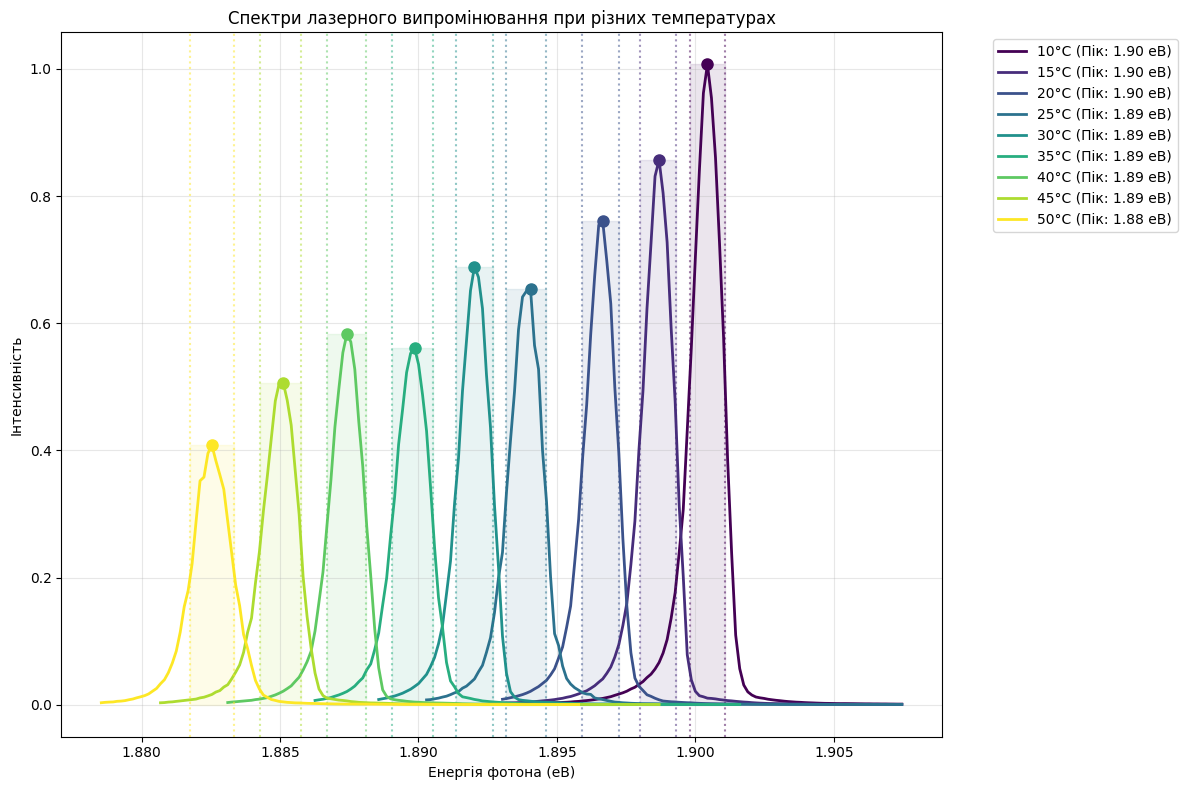

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, electron_volt as eV
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os

def load_and_convert_spectrum(filename):
    """Завантаження спектру та конвертація в енергетичне представлення"""
    try:
        data = np.loadtxt(filename, skiprows=1)
    except:
        data = np.loadtxt(filename)

    wavelength_nm = data[:, 0]
    intensity = data[:, 1]

    # Конвертація в енергію (еВ)
    wavelength_m = wavelength_nm * 1e-9
    energy_eV = (h * c) / (wavelength_m * eV)

    # Сортування за енергією
    sort_idx = np.argsort(energy_eV)
    return energy_eV[sort_idx], intensity[sort_idx]

def calculate_fwhm(energy, intensity):
    """Розрахунок напівширини спектра"""
    max_intensity = np.max(intensity)
    half_max = max_intensity / 2
    peak_energy = energy[np.argmax(intensity)]

    # Знаходимо точки перетину з half_max
    interp_func = interp1d(energy, intensity - half_max, kind='linear')
    roots = []
    for i in range(len(energy)-1):
        if (intensity[i] - half_max) * (intensity[i+1] - half_max) <= 0:
            try:
                root = brentq(interp_func, energy[i], energy[i+1])
                roots.append(root)
            except ValueError:
                continue

    if len(roots) >= 2:
        return peak_energy, max_intensity, roots[0], roots[1], roots[1] - roots[0]
    return peak_energy, max_intensity, None, None, 0

def plot_all_spectra(temperatures):
    """Візуалізація всіх спектрів з позначеннями"""
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(temperatures)))

    for temp, color in zip(temperatures, colors):
        filename = f"{temp} degrees.txt"
        if not os.path.exists(filename):
            continue

        energy, intensity = load_and_convert_spectrum(filename)
        peak_energy, max_intensity, left, right, fwhm = calculate_fwhm(energy, intensity)

        # Малюємо спектр
        label = f'{temp}°C (Пік: {peak_energy:.2f} еВ)'
        plt.plot(energy, intensity, '-', color=color, label=label, linewidth=2)

        # Позначаємо пік
        plt.plot(peak_energy, max_intensity, 'o', color=color, markersize=8)

        # Позначаємо FWHM
        if left is not None and right is not None:
            plt.axvline(x=left, color=color, linestyle=':', alpha=0.5)
            plt.axvline(x=right, color=color, linestyle=':', alpha=0.5)
            plt.fill_betweenx([0, max_intensity], left, right,
                            color=color, alpha=0.1)



    plt.title('Спектри лазерного випромінювання при різних температурах')
    plt.xlabel('Енергія фотона (еВ)')
    plt.ylabel('Інтенсивність')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main():
    temperatures = [10, 15, 20, 25, 30, 35, 40, 45, 50]
    plot_all_spectra(temperatures)

if __name__ == "__main__":
    main()

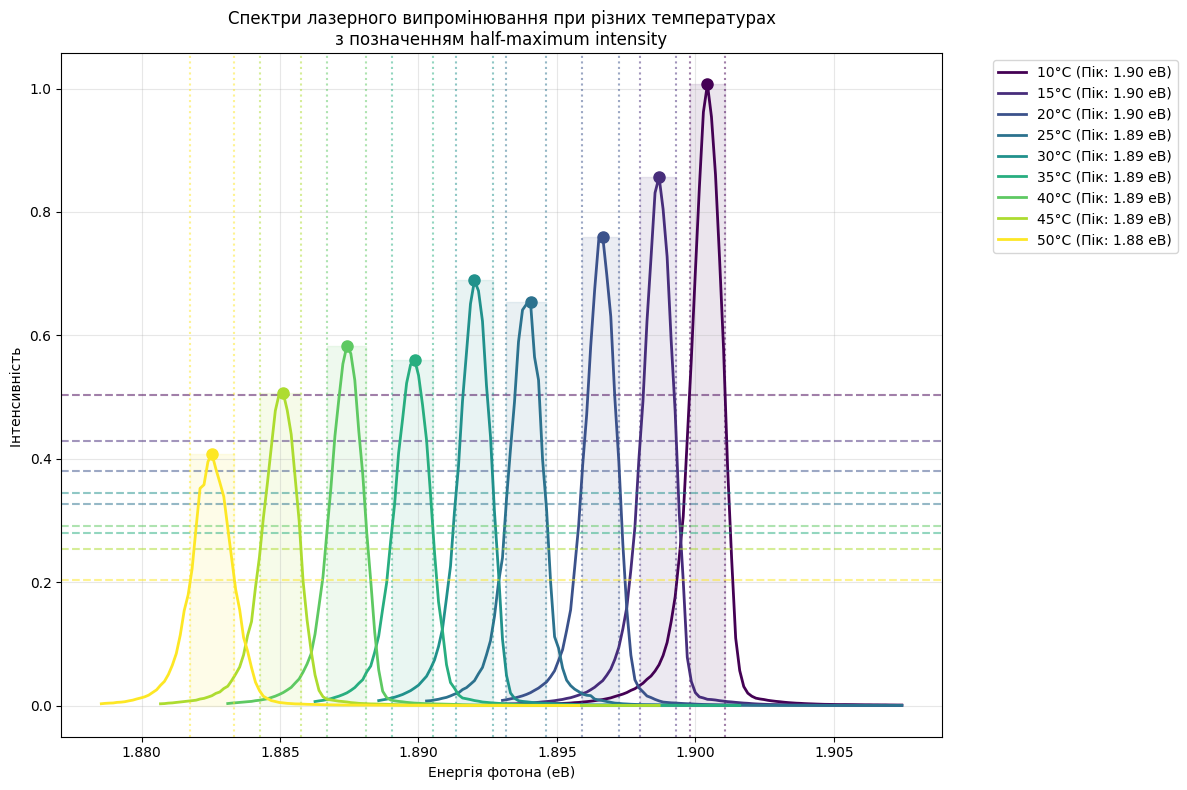

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, electron_volt as eV
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os

def load_and_convert_spectrum(filename):
    """Завантаження спектру та конвертація в енергетичне представлення"""
    try:
        data = np.loadtxt(filename, skiprows=1)
    except:
        data = np.loadtxt(filename)

    wavelength_nm = data[:, 0]
    intensity = data[:, 1]

    # Конвертація в енергію (еВ)
    wavelength_m = wavelength_nm * 1e-9
    energy_eV = (h * c) / (wavelength_m * eV)

    # Сортування за енергією
    sort_idx = np.argsort(energy_eV)
    return energy_eV[sort_idx], intensity[sort_idx]

def calculate_fwhm(energy, intensity):
    """Розрахунок напівширини спектра"""
    max_intensity = np.max(intensity)
    half_max = max_intensity / 2
    peak_energy = energy[np.argmax(intensity)]

    # Знаходимо точки перетину з half_max
    interp_func = interp1d(energy, intensity - half_max, kind='linear')
    roots = []
    for i in range(len(energy)-1):
        if (intensity[i] - half_max) * (intensity[i+1] - half_max) <= 0:
            try:
                root = brentq(interp_func, energy[i], energy[i+1])
                roots.append(root)
            except ValueError:
                continue

    if len(roots) >= 2:
        return peak_energy, max_intensity, half_max, roots[0], roots[1], roots[1] - roots[0]
    return peak_energy, max_intensity, half_max, None, None, 0

def plot_all_spectra(temperatures):
    """Візуалізація всіх спектрів з позначеннями"""
    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(temperatures)))

    for temp, color in zip(temperatures, colors):
        filename = f"{temp} degrees.txt"
        if not os.path.exists(filename):
            continue

        energy, intensity = load_and_convert_spectrum(filename)
        peak_energy, max_intensity, half_max, left, right, fwhm = calculate_fwhm(energy, intensity)

        # Малюємо спектр
        label = f'{temp}°C (Пік: {peak_energy:.2f} еВ)'
        plt.plot(energy, intensity, '-', color=color, label=label, linewidth=2)

        # Позначаємо пік
        plt.plot(peak_energy, max_intensity, 'o', color=color, markersize=8)

        # Додаємо лінію half-maximum
        plt.axhline(y=half_max, color=color, linestyle='--', alpha=0.5)

        # Позначаємо FWHM
        if left is not None and right is not None:
            plt.axvline(x=left, color=color, linestyle=':', alpha=0.5)
            plt.axvline(x=right, color=color, linestyle=':', alpha=0.5)
            plt.fill_betweenx([0, max_intensity], left, right,
                            color=color, alpha=0.1)



    plt.title('Спектри лазерного випромінювання при різних температурах\nз позначенням half-maximum intensity')
    plt.xlabel('Енергія фотона (еВ)')
    plt.ylabel('Інтенсивність ')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main():
    temperatures = [10, 15, 20, 25, 30, 35, 40, 45, 50]
    plot_all_spectra(temperatures)

if __name__ == "__main__":
    main()

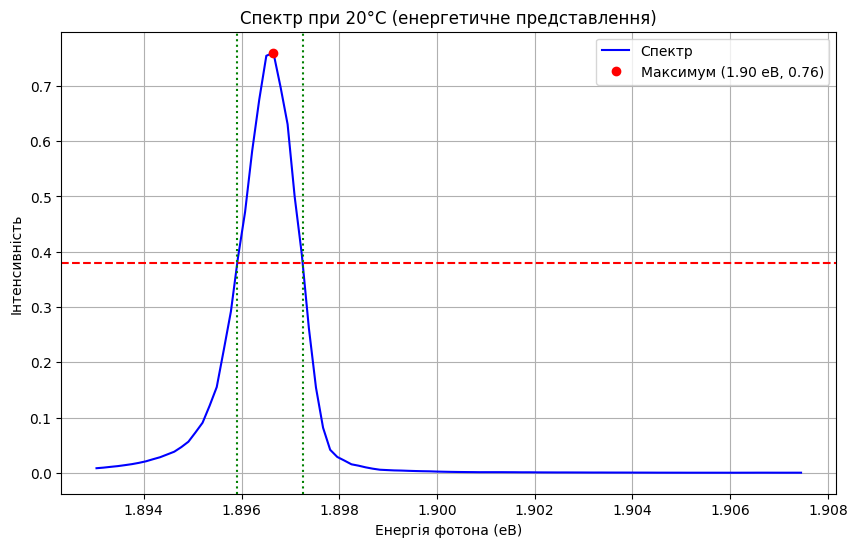


Результати аналізу спектрів:
+-------------+------------+-------------+-----------+-----------+
|   Темп (°C) |   Темп (K) |   FWHM (еВ) |   kT (еВ) |   FWHM/kT |
+=============+============+=============+===========+===========+
|          10 |   283.1500 |      0.0013 |    0.0244 |    0.0527 |
+-------------+------------+-------------+-----------+-----------+
|          15 |   288.1500 |      0.0013 |    0.0248 |    0.0526 |
+-------------+------------+-------------+-----------+-----------+
|          20 |   293.1500 |      0.0013 |    0.0253 |    0.0529 |
+-------------+------------+-------------+-----------+-----------+
|          25 |   298.1500 |      0.0014 |    0.0257 |    0.0562 |
+-------------+------------+-------------+-----------+-----------+
|          30 |   303.1500 |      0.0013 |    0.0261 |    0.0516 |
+-------------+------------+-------------+-----------+-----------+
|          35 |   308.1500 |      0.0015 |    0.0266 |    0.0565 |
+-------------+------------+----

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import Boltzmann as kB, h, c, electron_volt as eV
from scipy.interpolate import interp1d
from scipy.optimize import brentq
import os
from tabulate import tabulate

def load_and_convert_spectrum(filename):
    """Завантаження спектру та конвертація в енергетичне представлення"""
    try:
        data = np.loadtxt(filename, skiprows=1)
    except:
        data = np.loadtxt(filename)

    wavelength_nm = data[:, 0]  # довжина хвилі в нанометрах
    intensity = data[:, 1]

    # Конвертація енергії (еВ)
    wavelength_m = wavelength_nm * 1e-9
    energy_eV = (h * c) / (wavelength_m * eV)  # E = hc/λ

    # Сортуємо за енергією (від меншої до більшої)
    sort_idx = np.argsort(energy_eV)
    energy_eV = energy_eV[sort_idx]
    intensity = intensity[sort_idx]

    return energy_eV, intensity

def calculate_fwhm(energy, intensity, plot=False, temp=None):
    """Розрахунок напівширини в енергетичному представленні"""
    if len(energy) == 0:
        return 0

    max_intensity = np.max(intensity)
    max_idx = np.argmax(intensity)
    half_max = max_intensity / 2
    peak_energy = energy[max_idx]

    # Знаходимо точки перетину з half_max
    crossing_points = []
    for i in range(len(intensity)-1):
        if (intensity[i] - half_max) * (intensity[i+1] - half_max) <= 0:
            crossing_points.append(i)

    if len(crossing_points) < 2:
        return 0

    # Точний розрахунок коренів
    interp_func = interp1d(energy, intensity - half_max, kind='linear')
    roots = []
    for i in crossing_points[:2]:
        try:
            root = brentq(interp_func, energy[i], energy[i+1])
            roots.append(root)
        except ValueError:
            continue

    if len(roots) < 2:
        return 0

    fwhm = abs(roots[1] - roots[0])  # абсолютне значення різниці

    if plot and temp is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(energy, intensity, 'b-', label='Спектр')

        # Позначаємо максимум
        plt.plot(peak_energy, max_intensity, 'ro',
                label=f'Максимум ({peak_energy:.2f} еВ, {max_intensity:.2f})')

        # Лінії FWHM
        plt.axhline(y=half_max, color='r', linestyle='--')
        plt.axvline(x=roots[0], color='g', linestyle=':')
        plt.axvline(x=roots[1], color='g', linestyle=':')

        plt.title(f'Спектр при {temp}°C (енергетичне представлення)')
        plt.xlabel('Енергія фотона (еВ)')
        plt.ylabel('Інтенсивність')
        plt.legend()
        plt.grid(True)
        plt.show()

    return fwhm

def analyze_spectra(temperatures):
    """Аналіз спектрів при різних температурах"""
    results = []

    for temp in temperatures:
        filename = f"{temp} degrees.txt"
        if not os.path.exists(filename):
            print(f"Файл {filename} не знайдено, пропускаємо...")
            continue

        try:
            energy, intensity = load_and_convert_spectrum(filename)

            # Візуалізація тільки для 20°C
            plot_example = (temp == 20)
            fwhm_eV = calculate_fwhm(energy, intensity, plot=plot_example, temp=temp)

            T_K = temp + 273.15
            kT_eV = (kB * T_K) / eV  # kT в еВ

            results.append([
                temp,
                f"{T_K:.2f}",
                f"{fwhm_eV:.4f}",
                f"{kT_eV:.4f}",
                f"{fwhm_eV/kT_eV:.4f}"
            ])
        except Exception as e:
            print(f"Помилка при обробці {filename}: {e}")
            continue

    return results

def print_results_table(results):
    """Вивід результатів у вигляді таблиці"""
    headers = [
        "Темп (°C)",
        "Темп (K)",
        "FWHM (еВ)",
        "kT (еВ)",
        "FWHM/kT"
    ]

    print("\nРезультати аналізу спектрів:")
    print(tabulate(results, headers=headers, tablefmt="grid", floatfmt=".4f"))
    print("\nПримітки:")
    print("- Всі енергії приведені в електрон-вольтах (еВ)")
    print("- kT: теплова енергія, де k = 8.617×10⁻⁵ еВ/K (стала Больцмана)")
    print("- FWHM: півширина спектра випромінювання")

def main():
    temperatures = [10, 15, 20, 25, 30, 35, 40, 45, 50]
    results = analyze_spectra(temperatures)
    print_results_table(results)

if __name__ == "__main__":
    main()

**Залежність енергії кванту, що відповідає максимуму в спектрі від температури, та оцінка температурного коефіцієнту залежності.**

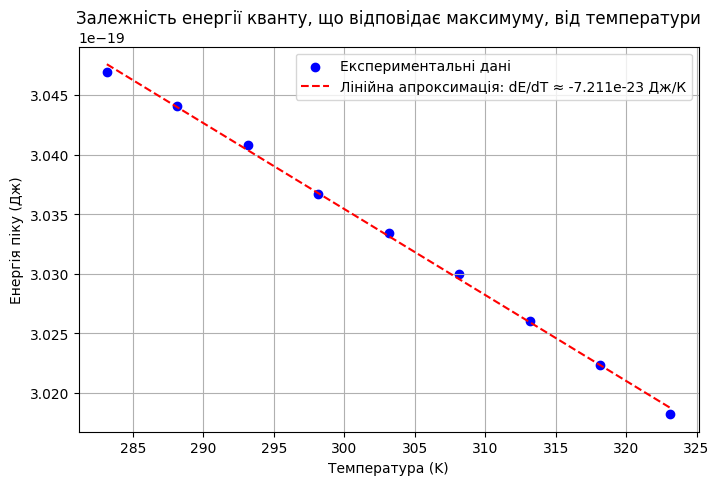


Результати аналізу:
Температурний коефіцієнт dE/dT = -7.211e-23 Дж/К
Коефіцієнт детермінації R² = 0.998


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def find_energy_max(energies, intensities):
    """Знаходить енергію, що відповідає максимуму інтенсивності"""
    max_index = np.argmax(intensities)
    return energies[max_index]

# Створення списків для аналізу
temperatures_C = []  # Температури в градусах Цельсія
E_max_values = []

for temp_C, (energies, intensities) in data.items():
    E_max = find_energy_max(energies, intensities)
    temperatures_C.append(temp_C)
    E_max_values.append(E_max)

# Перетворюємо температури в Кельвіни
temperatures_K = np.array(temperatures_C) + 273.15
E_max_values = np.array(E_max_values)

# Лінійна апроксимація (оцінка температурного коефіцієнта)
slope, intercept, r_value, _, _ = linregress(temperatures_K, E_max_values)

# Побудова графіка
plt.figure(figsize=(8, 5))
plt.scatter(temperatures_K, E_max_values, label="Експериментальні дані", color='blue')
plt.plot(temperatures_K, slope * temperatures_K + intercept, 'r--',
         label=f"Лінійна апроксимація: dE/dT ≈ {slope:.3e} Дж/К")
plt.xlabel("Температура (K)")
plt.ylabel("Енергія піку (Дж)")
plt.title("Залежність енергії кванту, що відповідає максимуму, від температури")
plt.legend()
plt.grid(True)
plt.savefig("E_max_vs_Temperature.png", dpi=300, bbox_inches='tight')
plt.show()

# Вивід результатів
print("\nРезультати аналізу:")
print(f"Температурний коефіцієнт dE/dT = {slope:.3e} Дж/К")
print(f"Коефіцієнт детермінації R² = {r_value**2:.3f}")

Переведемо температурний коефіцієнт в еВ/К:


dE/dT ≈ -7.211e-23 Дж/К = -0.00045 еВ/К

**Тобто отримали, що температурний коефіцієнт дорівнює -0.45 меВ/К**


**Піки інтенсивності:**

*Температура - довжина хвилі, нм - інтенсивність - енергія*

10 -     652.40       -   1.007054e+00  - 3,0469

15 -     653.00     -     8.568010e-01 -

20 -     653.70      -    7.599507e-01 -

25 -     654.60       -   6.533590e-01 -

30 -     655.30     -     6.890731e-01 -

35 -     656.05    -     5.609119e-01 -

40 -     656.90     -     5.827657e-01 -

45 -     657.70     -     5.063355e-01 -

50 -     658.60    -      4.081536e-01 - 3,018


---